In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

# SIR Base

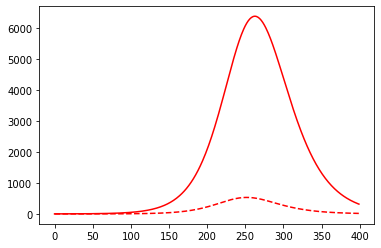

In [2]:
class SIR_base:
    def __init__(self, infection_rate, recovered_rate, death_rate, population=100000):

        self._population = population
        self._infection_rate = infection_rate
        self._recovered_rate = recovered_rate
        self._death_rate = death_rate
        self._simulation = None

    def run(self, T=1000, initial_active_cases=1):

        self._simulation = pd.DataFrame(
            0.0,
            columns=[
                "susceptible",
                "confirmed_cases",
                "active_cases",
                "new_cases",
                "recovered",
                "deaths",
            ],
            index=range(T),
        )

        self._simulation.at[0, "susceptible"] = self._population - initial_active_cases
        self._simulation.at[0, "active_cases"] = initial_active_cases
        self._simulation.at[0, "confirmed_cases"] = initial_active_cases

        for t in range(1, T):
            self._simulation.at[t, "new_cases"] = (
                self._infection_rate
                * self._simulation.active_cases[t - 1]
                * self._simulation.susceptible[t - 1]
                / self._population
            )
            recovered = self._recovered_rate * self._simulation.active_cases[t - 1]
            deaths = self._death_rate * self._simulation.active_cases[t - 1]
            self._simulation.at[t, "susceptible"] = (
                self._simulation.susceptible[t - 1] - self._simulation.new_cases[t]
            )
            self._simulation.at[t, "active_cases"] = (
                self._simulation.active_cases[t - 1]
                + self._simulation.new_cases[t]
                - recovered
                - deaths
            )
            self._simulation.at[t, "confirmed_cases"] = (
                self._simulation.confirmed_cases[t - 1] + self._simulation.new_cases[t]
            )
            self._simulation.at[t, "recovered"] = (
                self._simulation.recovered[t - 1] + recovered
            )
            self._simulation.at[t, "deaths"] = self._simulation.deaths[t - 1] + deaths

        return self._simulation

    def plot(self, cumulative=False):

        if cumulative is True:
            plt.plot(self._simulation.susceptible, "--k")
            plt.plot(self._simulation.confirmed_cases, "-k")
            plt.plot(self._simulation.active_cases, "-r")
            plt.plot(self._simulation.recovered, "-g")
            plt.plot(self._simulation.deaths, "--r")
        else:
            plt.plot(self._simulation.active_cases, "-r")
            plt.plot(self._simulation.new_cases, "--r")


m = SIR_base(infection_rate=0.12, recovered_rate=0.05, death_rate=0.03)
m.run(T=400)
m.plot(cumulative=False)

In [5]:
def data_download(filename):

    url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"
    df = pd.read_csv(url + filename)
    df["Province/State"] = df["Province/State"].map(
        lambda x: "" if pd.isna(x) else "__" + x
    )
    df = df.assign(country=df["Country/Region"] + df["Province/State"])
    df.pop("Lat")
    df.pop("Long")
    df.pop("Province/State")
    df.pop("Country/Region")
    df = df.set_index("country")
    df = df.transpose()
    df.columns = [x.lower().replace(" ", "_") for x in df.columns]
    df = df.reset_index()
    df = df.rename(columns={"index": "fecha"})
    df.fecha = df.fecha.map(lambda x: "0" + x if len(x) == 7 else x)
    df.fecha = df.fecha.map(lambda x: "20" + x[-2:] + "-" + x[:2] + "-" + x[3:5])
    return df


CONFIRMED = data_download("time_series_covid19_confirmed_global.csv")
DEATHS = data_download("time_series_covid19_deaths_global.csv")
RECOVERED = data_download("time_series_covid19_recovered_global.csv")

In [159]:
class SIR_adaptive:
    def __init__(self, death_rate, population=100000):

        self._population = population
        self._death_rate = death_rate
        self._simulation = None

    def run(
        self,
        historical_confirmed_cases,
        historical_recovered_cases,
        historical_death_cases,
        T=1000,
    ):

        self._simulation = pd.DataFrame(
            0.0,
            columns=[
                "susceptible",
                "confirmed_cases",
                "active_cases",
                "new_cases",
                "recovered",
                "deaths",
                "beta",
                "recovered_rate",
                "death_rate",
                "phi",
            ],
            index=range(T),
        )

        
        
        for t in range(0, len(historical_confirmed_cases)):

            self._simulation.at[t, "confirmed_cases"] = historical_confirmed_cases[t]
            self._simulation.at[t, "recovered"] = historical_recovered_cases[t]
            self._simulation.at[t, "deaths"] = historical_death_cases[t]

            self._simulation.at[t, "susceptible"] = (
                self._population - historical_confirmed_cases[t]
            )

            if t > 0:
                self._simulation.at[t, "active_cases"] = (
                    self._simulation.confirmed_cases[t]
                    - self._simulation.recovered[t]
                    - self._simulation.deaths[t]
                )
                if self._simulation.active_cases[t - 1] > 0:
                    
                    self._simulation.at[t, "beta"] = (
                        self._simulation.active_cases[t]
                        - self._simulation.active_cases[t - 1]
                    ) / self._simulation.active_cases[t - 1]
                    
                    self._simulation.at[t, "recovered_rate"] = (
                        self._simulation.recovered[t] - self._simulation.recovered[t-1]
                    ) / self._simulation.active_cases[t - 1]
                    
                    self._simulation.at[t, "death_rate"] = (
                        self._simulation.deaths[t] - self._simulation.deaths[t-1]
                    ) / self._simulation.active_cases[t - 1]
                    
                else:
                    self._simulation.at[t, "beta"] = self._simulation.beta[t - 1]
                    self._simulation.at[t, "recovered_rate"] = self._simulation.recovered_rate[t - 1]
                    self._simulation.at[t, "death_rate"] = self._simulation.death_rate[t - 1]
                    
                if self._simulation.beta[t] < 0:
                    self._simulation.at[t, "beta"] = self._simulation.beta[t - 1]
                    
                if self._simulation.beta[t-1] > 0:
                    self._simulation.at[t, 'phi'] = self._simulation.beta[t] / self._simulation.beta[t-1]
                     
                    
        for t in range(len(historical_confirmed_cases), T):

            self._simulation.at[t, "beta"] = self._simulation.beta[t - 1]
            self._simulation.at[t, "recovered_rate"] = self._simulation.recovered_rate[t - 1]
            self._simulation.at[t, "death_rate"] = self._simulation.death_rate[t - 1]

            self._simulation.at[t, "new_cases"] = (
                self._simulation.beta[t]
                * self._simulation.active_cases[t - 1]
                * self._simulation.susceptible[t - 1]
                / self._population
            )
            
            recovered = self._simulation.recovered_rate[t] * self._simulation.active_cases[t - 1]
            
            deaths = self._simulation.death_rate[t] * self._simulation.active_cases[t - 1]
            
            self._simulation.at[t, "susceptible"] = (
                self._simulation.susceptible[t - 1] - self._simulation.new_cases[t]
            )
            self._simulation.at[t, "active_cases"] = (
                self._simulation.active_cases[t - 1]
                + self._simulation.new_cases[t]
                - recovered
                - deaths
            )
            self._simulation.at[t, "confirmed_cases"] = (
                self._simulation.confirmed_cases[t - 1] + self._simulation.new_cases[t]
            )
            
            
            self._simulation.at[t, "recovered"] = (
                self._simulation.recovered[t - 1] + recovered
            )
            self._simulation.at[t, "deaths"] = self._simulation.deaths[t - 1] + deaths

        return self._simulation

    def plot(self, cumulative=False):

        if cumulative is True:
            plt.plot(self._simulation.confirmed_cases, "-k", linewidth=2)
            plt.plot(self._simulation.active_cases, "-r")
            plt.plot(self._simulation.recovered, "-g")
            plt.plot(self._simulation.deaths, "--r")
        else:
            plt.plot(self._simulation.active_cases, "-r")
            plt.plot(self._simulation.new_cases, "--r")

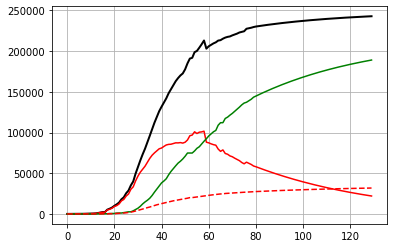

In [170]:
country = "spain"

confirmed_cases = CONFIRMED[country]
confirmed_cases = confirmed_cases[confirmed_cases > 5]
T0 = confirmed_cases.index[0]
confirmed_cases = confirmed_cases.tolist()
recovered_cases = RECOVERED[country][T0:].tolist()
death_cases = DEATHS[country][T0:].tolist()

m = SIR_adaptive(death_rate=0.002,population=300000)

m.run(confirmed_cases, recovered_cases, death_cases, T=130)

m.plot(cumulative=True)
plt.grid()

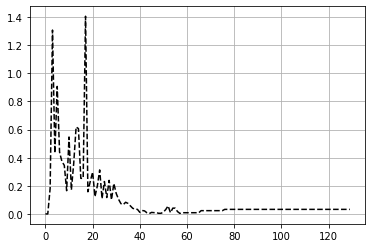

In [171]:
plt.plot(m._simulation.beta, "--k")
plt.grid()

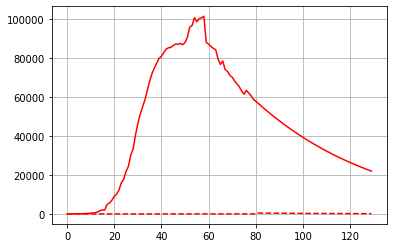

In [172]:
m.plot(cumulative=False)
plt.grid()

In [163]:
m._simulation.death_rate

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
125    0.002345
126    0.002345
127    0.002345
128    0.002345
129    0.002345
Name: death_rate, Length: 130, dtype: float64

In [173]:
x = list('abcdefg')
x[:-1]

['a', 'b', 'c', 'd', 'e', 'f']

In [174]:
x[1:]

['b', 'c', 'd', 'e', 'f', 'g']